In [1]:
# %pip install seaborn


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [10]:
parasitized_path = r"C:\Users\Bright\Desktop\ds_today\project\data\cell_images\Parasitized"
uninfected_path = r"C:\Users\Bright\Desktop\ds_today\project\data\cell_images\Uninfected"

### Check class balance between two classifications
Observations
1. Plot shows that the classes are equally balanced

In [11]:

class_counts = {
    "Parasitized" : len(os.listdir(parasitized_path))
  , "Uninfected" : len(os.listdir(uninfected_path))
}

pd.DataFrame(
    class_counts.items()
    , columns= ["Class", "Counts"])

,Class,Counts
0,Parasitized,13780
1,Uninfected,13780


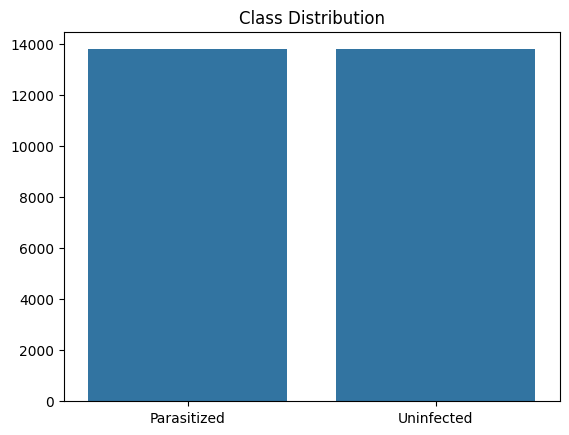

In [5]:
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution")
plt.show()



### Visualize Sample Images
Observations
1. Parasitized cells contain dark spots and are more irregularly shaped
2. Uninfected cells have a uniform coloration and regularly shaped

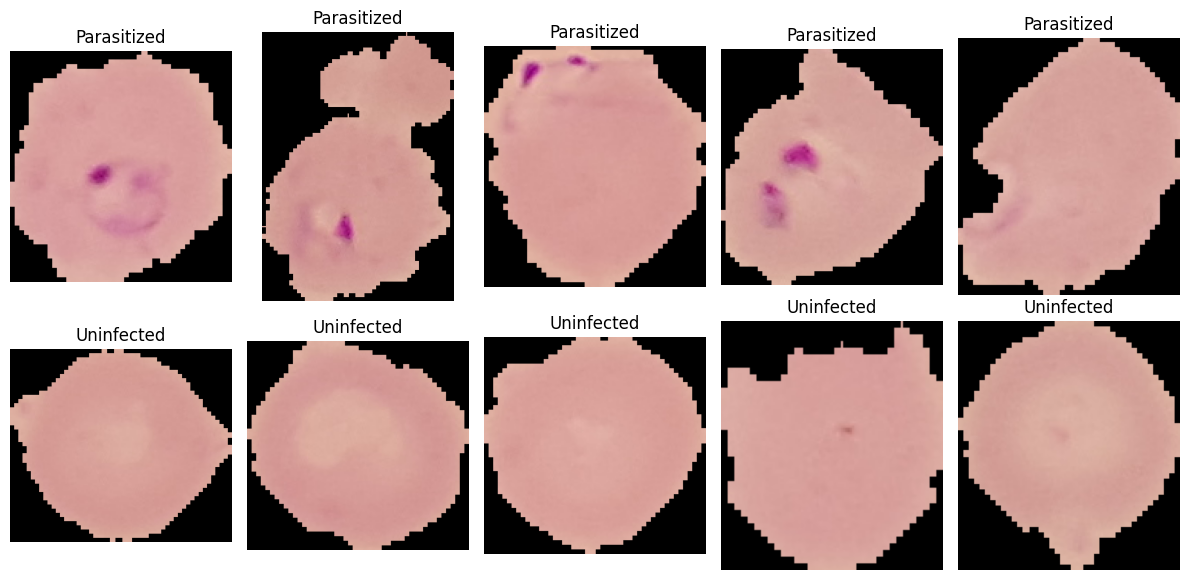

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12,6))

for i, filename in enumerate(os.listdir(parasitized_path)[:5]):
    img = Image.open(os.path.join(parasitized_path, filename))
    axes[0, i].imshow(img)
    axes[0, i].axis("off")
    axes[0, i].set_title("Parasitized")

for i, filename in enumerate(os.listdir(uninfected_path)[:5]):
    img = Image.open(os.path.join(uninfected_path, filename))
    axes[1, i].imshow(img)
    axes[1, i].axis("off")
    axes[1, i].set_title("Uninfected")

plt.tight_layout()
plt.show()

### Check Image Dimensions

In [7]:
image_extensions = (".png", ".jpg", ".jpeg")

sizes = []

for folder in [parasitized_path, uninfected_path]:
    for file in os.listdir(folder):
        if file.lower().endswith(image_extensions):
            img = Image.open(os.path.join(folder, file))
            sizes.append(img.size)

In [8]:
size_df = pd.DataFrame(
    sizes,
    columns=["Width", "Height"]
)

size_df.head()

,Width,Height
0,142,148
1,148,208
2,139,151
3,145,154
4,133,154


In [9]:
size_df.describe()

,Width,Height
count,27558.000000,27558.000000
mean,132.487154,132.983453
std,20.015949,20.619650
min,46.000000,40.000000
25%,121.000000,121.000000
50%,130.000000,130.000000
75%,142.000000,145.000000
max,394.000000,385.000000


### Observations
1. Images are not the same size dimensions.
2. A CNN requires consistent dimensions.
3. During preprocessing we'll need to resize all images to a similar size

### Visualization of the Distribution of Weight and Height

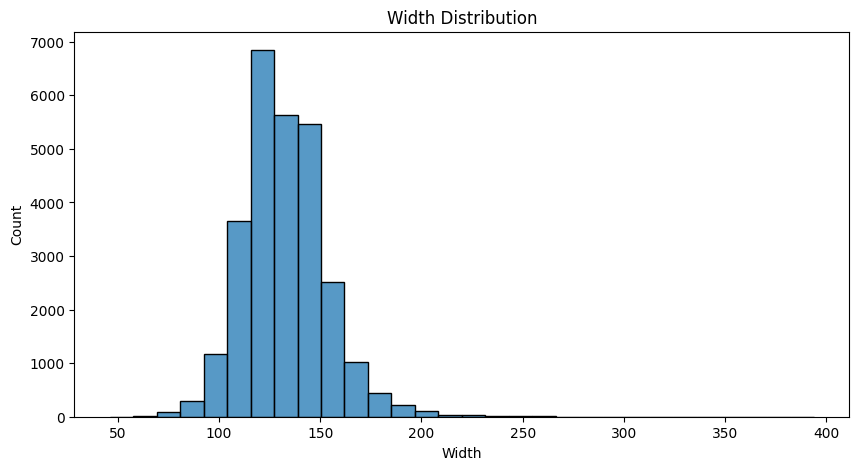

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    size_df["Width"],
    bins=30
)

plt.title("Width Distribution")
plt.show()

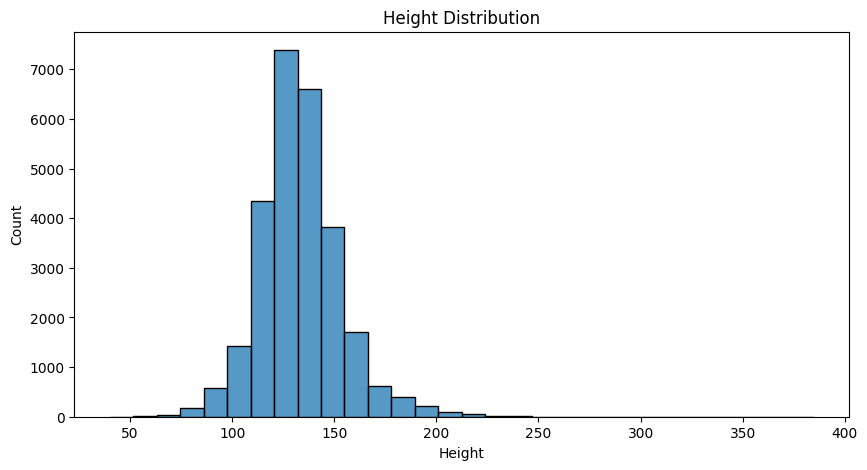

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    size_df["Height"],
    bins=30
)

plt.title("Height Distribution")
plt.show()

### Analyze Pixel Values
Observations
1. Image is an RGB  
2. The pixels are between 0 - 255
3. There is a need to normalize the dataset pixels

In [ ]:
img = np.array(
    Image.open(os.path.join(parasitized_path, os.listdir(parasitized_path)[0]))
)

print(img.shape)
print(img.min())
print(img.max())

(148, 142, 3)
0
232


### Exploratory Data Analysis Summary

The malaria dataset contains 27,560 cell images distributed equally between two classes: Parasitized (13,780 images) and Uninfected (13,780 images). After inspection, two non-image files (Thumbs.db) were identified and excluded, leaving 27,558 valid images for analysis.

Visual examination of the images revealed noticeable differences between classes. Parasitized cells often contain dark purple intracellular structures associated with malaria parasites, while uninfected cells generally exhibit a more uniform appearance without these features.

Image dimensions vary considerably across the dataset. Widths range from 46 to 394 pixels and heights range from 40 to 385 pixels, with average dimensions of approximately 132 × 133 pixels. This variability indicates that image resizing will be required prior to model training.

The dataset is balanced, reducing concerns regarding class imbalance and allowing standard classification metrics such as accuracy, precision, recall, F1-score, and confusion matrices to be used reliably during evaluation.
